In [9]:
import glob
import os
import numpy as np
import pandas as pd
import scipy.signal
import skimage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu

plt.style.use('styleNB.mplstyle')

def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell', 'position']):
        d_ = d_.copy().sort_values('interval')
        interval_frames = d_.interval.values[::frame_step]
        sampled = d_[d_['interval'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    return df_out

# Plot directed speed along x-axis
colors = sns.color_palette("tab10")
color_dict = {
    'Galvanin_WT': '#B8BABC',
    'Galvanin_KO': colors[1],
    '': colors[2]  
}

# Load in data

In [3]:
df_1 = pd.read_csv('../../data/processed_2D_tracking/20250406_isolated_zebrafish_keratocytes_tracking_filtered.csv')
df_2 = pd.read_csv('../../data/processed_2D_tracking/20250420_isolated_zebrafish_keratocytes_tracking_filtered.csv')
df = pd.concat([df_1, df_2], ignore_index=True)
df = df[df.E_V_cm != 5]

# Step 1: unit correction
## Note that videos were tracked in units of pixels. Conversion factors:
# Rio scope (AP samples): 1.547 pixels/um
# Oslo scope (NB samples): 1.530 pixel/um

# Make a copy to avoid modifying the original DataFrame in-place (optional but safe)
df_converted = df.copy()

# Apply conversion factor: NB = 1.53, AP = 1.547
df_converted.loc[df_converted['user'] == 'NB', ['x', 'y']] /= 1.53
df_converted.loc[df_converted['user'] == 'AP', ['x', 'y']] /= 1.547
df_converted['celltype'] = df_converted['celltype_genotype']
df = df_converted

df.head()

,Unnamed: 0,cell,frame,x,y,z,celltype,position,E_V_cm,date,trial,user,celltype_genotype
0,0,0,0,349.024110,196.442253,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
1,1,0,1,359.114003,194.286702,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
2,2,0,2,369.991581,196.799344,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
3,3,0,3,380.458097,202.806752,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
4,4,0,4,383.005824,214.212646,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT


In [4]:
# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype_genotype', 'E_V_cm', 'date', 'trial', 'user', 'cell', 'position']):
    frames = sorted(d_.frame.unique())
    
    # Filter: skip short tracks
    if len(frames) <= 10:
        continue

    min_frame = min(frames)
    d_ = d_.copy()
    d_['rel_frame'] = d_.frame - min_frame

    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)  # full resolution

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0]])
    
    positions = np.array(positions)
    if np.isnan(positions).any():
        continue

    # # Filter: ignore any non-moving cells 
    total_movement = np.sum(np.sqrt(np.sum(np.diff(positions, axis=0)**2, axis=1)))
    if total_movement < 20:
        continue

    # Keep untrimmed full-resolution track
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'position': g[-1],
            'interval': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1]
        })
    ], ignore_index=True)    

df_filtered_tracks['frame'] = df_filtered_tracks['interval']



# Plotting

## Trajectories

('Galvanin_KO', 0)
('Galvanin_KO', 1)
('Galvanin_KO', 3)
('Galvanin_WT', 0)
('Galvanin_WT', 1)
('Galvanin_WT', 3)


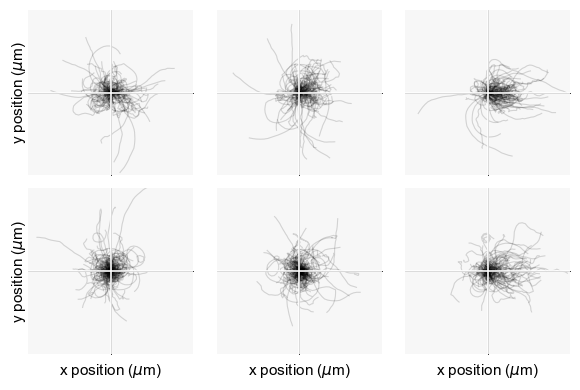

In [5]:
f, ax = plt.subplots(2, 3, figsize=(6, 4))
EF_dict = {0: 0, 1: 1, 3: 2}
dict_ax = {'Galvanin_WT': 0, 'Galvanin_KO': 1}


for g, d in df_filtered_tracks.groupby(['celltype', 'E_V_cm']):
    print(g)
    trajectories = []
    count_cell = 0
    for i, d_ in d.groupby(['cell', 'trial', 'date', 'user', 'position']):
        if len(d_) < 5:
            continue
        if count_cell > 126:
            continue


        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax_ = ax[dict_ax[g[0]], EF_dict[g[1]]]
        ax_.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)

        # Optional: mark final point faintly
        #ax_.scatter(x_rel[-1], y_rel[-1], s=2, color='black', alpha=0.1, zorder=5)

        count_cell += 1

    ax_ = ax[dict_ax[g[0]], EF_dict[g[1]]]

    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    ax_.set_xlim(-400, 400)
    ax_.set_ylim(-400, 400)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    ax_.set_xlabel(r'x position ($\mu$m)')
    ax_.set_ylabel(r'y position ($\mu$m)')

n_rows, n_cols = ax.shape

for r in range(n_rows):
    for c in range(n_cols):
        ax_ = ax[r, c]

        # Hide x labels if not in bottom row
        if r < n_rows - 1:
            ax_.set_xlabel('')
            ax_.tick_params(labelbottom=False)

        # Hide y labels if not in leftmost column
        if c > 0:
            ax_.set_ylabel('')
            ax_.tick_params(labelleft=False)

n_rows, n_cols = ax.shape

for r in range(n_rows):
    for c in range(n_cols):
        ax_ = ax[r, c]

        # Keep axis labels only on outer left and bottom
        if r < n_rows - 1:
            ax_.set_xlabel('')
        if c > 0:
            ax_.set_ylabel('')

        # Remove all tick labels
        ax_.set_xticklabels([])
        ax_.set_yticklabels([])

        # Optional: reduce tick mark length
        ax_.tick_params(length=0)
            
plt.tight_layout()
# f.savefig('../../figures/20250523_zebrafish_tracks.pdf', bbox_inches='tight')

## Average cosine theta of cell trajectories

/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_6425/2649322654.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')


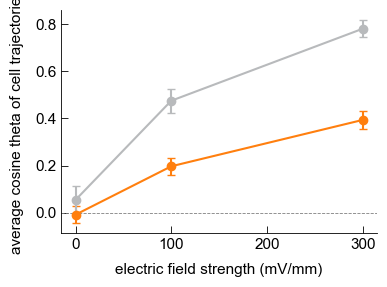

In [10]:
interval = 2
df_intervals = parse_trajectories(df_filtered_tracks, frame_step=interval)

def calc_cos_theta_net_per_trajectory(df):
    def cos_theta_net(d):
        dx = d['x'].iloc[-1] - d['x'].iloc[0]
        dy = d['y'].iloc[-1] - d['y'].iloc[0]
        v = np.array([dx, dy])
        e_field = np.array([1, 0])
        norm = np.linalg.norm(v)
        if norm == 0:
            return np.nan
        return np.dot(v, e_field) / norm

    group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'user', 'position', 'cell']
    return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')

df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df_intervals)

df_cos_theta_avg = df_cos_theta_net_all.groupby(['celltype', 'E_V_cm']).agg(
    mean_cos_theta_net=('cos_theta_net', 'mean'),
    sem_cos_theta_net=('cos_theta_net', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index()

fig, ax = plt.subplots(figsize=(4,3))

for celltype, group in df_cos_theta_avg.groupby('celltype'):
    ax.errorbar(
        group['E_V_cm'] * 100,  # convert to mV/mm if needed
        group['mean_cos_theta_net'],
        yerr=group['sem_cos_theta_net'],
        label=celltype,
        marker='o',
        capsize=3,
        lw=1.5,
        color = color_dict[celltype]
    )

ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('electric field strength (mV/mm)')
ax.set_ylabel('average cosine theta of cell trajectories')

plt.tight_layout()
plt.show()

/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_6425/2649322654.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')


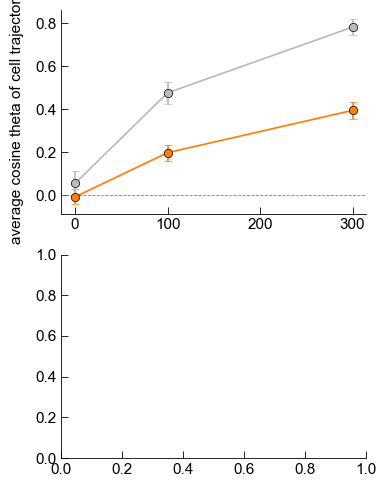

In [11]:
# Create plot with slightly different aspect ratio

df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df_intervals)

df_cos_theta_avg = df_cos_theta_net_all.groupby(['celltype', 'E_V_cm']).agg(
    mean_cos_theta_net=('cos_theta_net', 'mean'),
    sem_cos_theta_net=('cos_theta_net', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index()

fig, axs = plt.subplots(2, 1, figsize=(4, 5), sharex=False)

# Top plot: net directionality
ax_top = axs[0]
for celltype, group in df_cos_theta_avg.groupby('celltype'):
    ax_top.errorbar(
        group['E_V_cm'] * 100,  # V/cm to mV/mm
        group['mean_cos_theta_net'],
        yerr=group['sem_cos_theta_net'],
        label=celltype,
        marker='o',
        capsize=3,
        markersize=6,
        lw=1.25,
        color=color_dict[celltype],
        markeredgecolor='k',
        markeredgewidth=0.5
    )
ax_top.axhline(0, color='gray', linestyle='--')
ax_top.set_ylabel('average cosine theta of cell trajectories')

plt.tight_layout()
plt.show()

# fig.savefig('../../figures/Figure3_zebrafish_cosinetheta.pdf', bbox_inches='tight')


In [12]:
# Define cell types
celltypes = df_intervals.celltype.unique()

def perform_mannwhitney_cos_theta(df):
    results = []
    for ev in sorted(df['E_V_cm'].unique()):
        subset = df[df['E_V_cm'] == ev]
        group1 = subset[subset['celltype'] == celltypes[0]]['cos_theta_net'].dropna()
        group2 = subset[subset['celltype'] == celltypes[1]]['cos_theta_net'].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
            results.append({'E_V_cm': ev, 'statistic': stat, 'p_value': p, 'metric': 'cos_theta_net'})
    return pd.DataFrame(results)


# Run both tests
df_stats_cos = perform_mannwhitney_cos_theta(df_cos_theta_net_all)

# print summary
print(df_stats_cos)


   E_V_cm  statistic       p_value         metric
0       0    28723.0  3.095898e-01  cos_theta_net
1       1    19530.0  2.150614e-05  cos_theta_net
2       3    12857.5  1.159970e-08  cos_theta_net


In [13]:
# Create a new global unique cell ID per group
df_intervals['cell_global'] = (
    df_intervals['celltype'].astype(str) + '_' +
    df_intervals['date'].astype(str) + '_' +
    df_intervals['trial'].astype(str) + '_' +
    df_intervals['user'].astype(str) + '_' +
    df_intervals['position'].astype(str) + '_' +
    df_intervals['cell'].astype(str)
)

# Group and count
summary_stats = []
for (celltype, E_V_cm), df_group in df_intervals.groupby(['celltype', 'E_V_cm']):
    n_samples = df_group.groupby(['date', 'trial', 'user']).ngroups
    n_cells = df_group['cell_global'].nunique()

    summary_stats.append({
        'celltype': celltype,
        'E_V_cm': E_V_cm,
        'n_samples': n_samples,
        'n_cells': n_cells
    })

df_summary_stats = pd.DataFrame(summary_stats).sort_values(['celltype', 'E_V_cm'])
df_summary_stats

,celltype,E_V_cm,n_samples,n_cells
0,Galvanin_KO,0,4,373
1,Galvanin_KO,1,4,358
2,Galvanin_KO,3,4,313
3,Galvanin_WT,0,4,163
4,Galvanin_WT,1,4,144
5,Galvanin_WT,3,4,126
